In [1]:
import os
import math
import time
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Utils.CADDomainVisualizer import CADDomainVisualizer
from Utils.CADVisualizer   import CADVisualizer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell
from Training.MainTrain import NN_Trainer, TrainingConfig
from Decoder_CLasses.ContinuousVoronoiDecoder import ContinuousVoronoiDecoder
from Pred_NN_Classes.ppnet import PPNet
from scipy.spatial import Delaunay, Voronoi, voronoi_plot_2d, cKDTree

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)




Code Directory: /home/arash/HVD_SeedsBase
Test Step files Directory: /home/arash/HVD_SeedsBase/Testparts
device: cuda
PyVista backend: trame


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

# -----------------------
# Seed points
# -----------------------
real_seeds = np.array([
    [0.15, 0.22],
    [0.22, 0.70],
    [0.38, 0.60],
    [0.47, 0.82],
    [0.58, 0.18],
    [0.67, 0.48],
    [0.74, 0.77],
    [0.86, 0.32],
    [0.78, 0.92],
    [0.32, 0.38],
         [0.50, -0.5], 
    [1.5, 0.50], 
    [0.50, 1.5], 
    [-0.5, 0.50], 
    [-0.5, -0.5], [1.5, -0.5], [1.5, 1.5], [-0.5, 1.5],
], dtype=float)

guard_seeds = np.array([
     [0.50, -0.5], 
    [1.5, 0.50], 
    [0.50, 1.5], 
    [-0.5, 0.50], 
    [-0.5, -0.5], [1.5, -0.5], [1.5, 1.5], [-0.5, 1.5],
], dtype=float)

# Voronoi without guards
vor_no_guard = Voronoi(real_seeds)

# Voronoi with guards
points_with_guard = np.vstack([real_seeds, guard_seeds])
vor_guard = Voronoi(points_with_guard)

# -----------------------
# Plot
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)

# --- Without guards ---
voronoi_plot_2d(
    vor_no_guard,
    ax=axes[0],
    show_vertices=False,
    show_points=False,
    line_colors="black",
    line_width=1.5,
)
axes[0].scatter(
    real_seeds[:, 0], real_seeds[:, 1],
    color="red", s=60, label="Seeds"
)

axes[0].set_title("Without Guard Seeds")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect("equal")
axes[0].grid(True)

# --- With guards ---
voronoi_plot_2d(
    vor_guard,
    ax=axes[1],
    show_vertices=False,
    show_points=False,
    line_colors="black",
    line_width=1.5,
)
axes[1].scatter(
    real_seeds[:, 0], real_seeds[:, 1],
    color="red", s=60, label="Seeds"
)


axes[1].scatter(
    guard_seeds[:, 0], guard_seeds[:, 1],
    color="blue", s=60, label="Guard seeds"
)
axes[1].set_title("With Guard Seeds")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect("equal")
axes[1].grid(True)

axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

/tmp/ipykernel_261233/2422459839.py:94: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    :  - Label 'Shapes/Document' (2D)
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (BSpline)
Info    : [ 30%] Meshing curve 2 (BSpline)
Info    : [ 60%] Meshing curve 3 (BSpline)
Info    : [ 80%] Meshing curve 4 (BSpline)
Info    : Done meshing 1D (Wall 0.000429014s, CPU 0.000445s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.198653s, CPU 0.195518s)
Info    : 12920 nodes 25842 elements
Info    : Clearing all models and views...
Info    : Done clearing all models and views

=== Active Face Info ===
XYZ bounds:
  X: [-0.000000, 10.000000]  span=10.000000
  Y: [-0.000000, 10.000000]  span=10.000000
  Z: [-0.000000, 0.000000]  span=0.000000

UV bounds:
  U: [-10.000000, 0.000000]
  V: [0.000000, 10.000000]

Periodic:
  U periodic: False
  V periodic: False



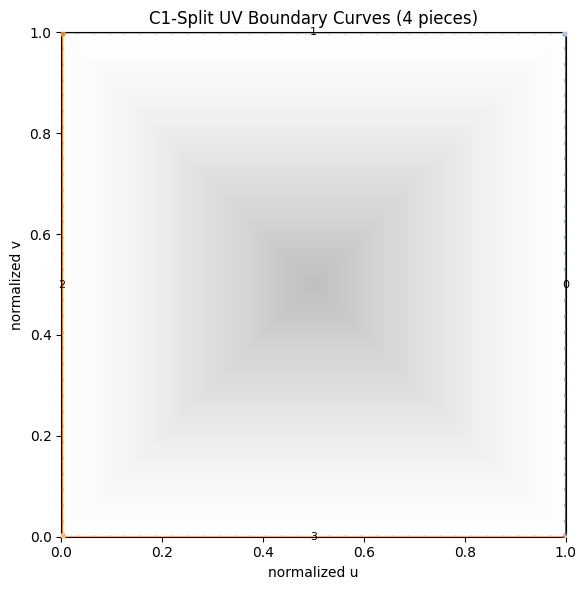

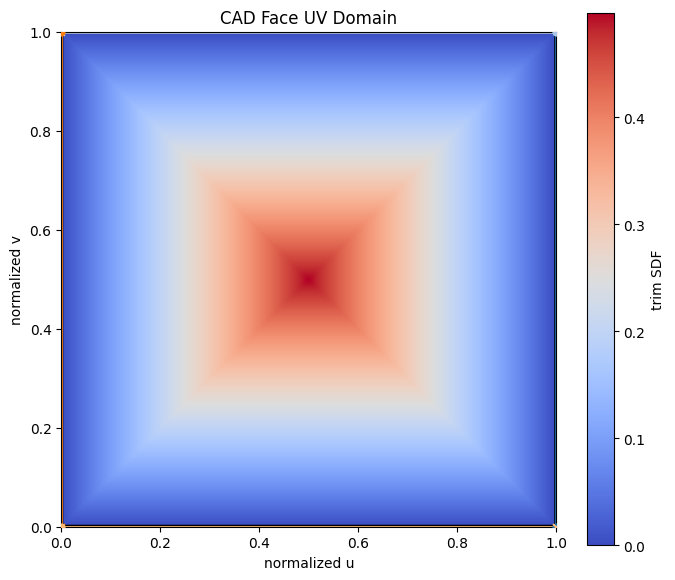

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x71033a568670_0&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x710310187550_1&reconnect=auto" class="pyvi…

In [3]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
ConeTaped = TesPartsDir / "ConeTaped.stp"
FreeFormCLosed = TesPartsDir / "FreeFormClosed.stp"
Planar = TesPartsDir / "Planar.stp"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"
FreeFormSurf4 = TesPartsDir / "FreeForm4.stp"
FreeFormBench = TesPartsDir / "FreeFormBench.stp"
FreeSharp1 = TesPartsDir / "FreeSharp1.stp"
FreeSharp2 = TesPartsDir / "FreeSharp2.stp"
SeatBr = TesPartsDir / "SeatBr.stp"
MouseBot = TesPartsDir / "MouseBot.stp"

shape_path = Planar

Face_Cad = CADTensorGenerator(
    device=device,
    seed_domain_mask_res=512,
    mesh_size_scale = 0.5,
)

cad_domain, face_mesh = Face_Cad.generate_from_file(shape_path)

dx,dy,dz = Face_Cad.print_face_info();

viz = CADDomainVisualizer(Face_Cad)
fig, ax = viz.plot_uv_boundary_curves()
viz.plot_uv_domain()


# --------------------------------------------------
# Visualize Gmsh mesh nodes as point cloud
# --------------------------------------------------

points_xyz = face_mesh["points_xyz"]

pts = points_xyz.detach().cpu().numpy()

cloud = pv.PolyData(pts)

plotter = pv.Plotter()
plotter.add_mesh(
    cloud,
    render_points_as_spheres=True,
    point_size=6,
)
plotter.show()

# --------------------------------------------------
# Visualize actual Gmsh triangular surface mesh
# --------------------------------------------------

points = face_mesh["points_xyz"].detach().cpu().numpy()
faces = face_mesh["pv_faces"].detach().cpu().numpy()

mesh = pv.PolyData(points, faces)

plotter = pv.Plotter()
plotter.add_mesh(
    mesh,
    show_edges=True,
)
plotter.show()

In [4]:
def random_seeds_min_dist(N, min_dist=0.08, seed=1, max_tries=10000, device="cpu"):
    torch.manual_seed(seed)

    seeds = []
    tries = 0

    while len(seeds) < N and tries < max_tries:
        p = torch.rand(2, device=device)

        if len(seeds) == 0:
            seeds.append(p)
        else:
            current = torch.stack(seeds, dim=0)
            d = torch.linalg.norm(current - p[None, :], dim=-1)

            if d.min() >= min_dist:
                seeds.append(p)

        tries += 1

    if len(seeds) < N:
        raise RuntimeError(
            f"Could only generate {len(seeds)} seeds with min_dist={min_dist}."
        )

    return torch.stack(seeds, dim=0)




In [5]:
test_seed_cases11 = {
    "normal_random": random_seeds_min_dist(
        N=100, min_dist=0.001, seed=21, device=device
    ),

    # ------------------------------------------------------------------
    # Duplicate tolerance
    # ------------------------------------------------------------------
    "near_duplicate_pair": torch.tensor([
        [0.20, 0.20],
        [0.200001, 0.200001],
        [0.45, 0.25],
        [0.70, 0.20],
        [0.30, 0.60],
        [0.50, 0.60],
        [0.70, 0.60],
        [0.40, 0.85],
        [0.60, 0.85],
        [0.85, 0.75],
    ], dtype=torch.float32, device=device),

    # ------------------------------------------------------------------
    # Very dense cluster
    # ------------------------------------------------------------------
    "clustered_dense": torch.tensor([
        [0.5000,0.5000],
        [0.5008,0.5004],
        [0.5015,0.5012],
        [0.4995,0.5010],
        [0.4988,0.4998],
        [0.5020,0.4995],
        [0.20,0.20],
        [0.80,0.20],
        [0.20,0.80],
        [0.80,0.80],
    ], dtype=torch.float32, device=device),

    # ------------------------------------------------------------------
    # Nearly collinear
    # ------------------------------------------------------------------
    "nearly_collinear": torch.tensor([
        [0.10,0.5000],
        [0.20,0.5002],
        [0.30,0.4998],
        [0.40,0.5001],
        [0.50,0.4999],
        [0.60,0.5002],
        [0.70,0.4998],
        [0.80,0.5001],
        [0.35,0.80],
        [0.65,0.20],
    ], dtype=torch.float32, device=device),

    # ------------------------------------------------------------------
    # Nearly cocircular (Delaunay flip)
    # ------------------------------------------------------------------
    "nearly_cocircular": torch.tensor([
        [0.30,0.50],
        [0.50,0.70],
        [0.70,0.50],
        [0.500001,0.30],
        [0.20,0.20],
        [0.80,0.20],
        [0.20,0.80],
        [0.80,0.80],
        [0.10,0.50],
        [0.90,0.50],
    ], dtype=torch.float32, device=device),

    # ------------------------------------------------------------------
    # Perfect symmetry
    # ------------------------------------------------------------------
    "perfect_square": torch.tensor([
        [0.25,0.25],
        [0.75,0.25],
        [0.75,0.75],
        [0.25,0.75],
        [0.50,0.50],
        [0.10,0.10],
        [0.90,0.10],
        [0.90,0.90],
        [0.10,0.90],
        [0.50,0.90],
    ], dtype=torch.float32, device=device),

    # ------------------------------------------------------------------
    # Heavy boundary occupancy
    # ------------------------------------------------------------------
    "boundary_heavy": torch.tensor([
        [0.00,0.00],
        [1.00,0.00],
        [1.00,1.00],
        [0.00,1.00],
        [0.50,0.00],
        [1.00,0.50],
        [0.50,1.00],
        [0.00,0.50],
        [0.50,0.50],
        [0.25,0.75],
    ], dtype=torch.float32, device=device),

    # ------------------------------------------------------------------
    # Seeds almost on boundary
    # ------------------------------------------------------------------
    "near_boundary": torch.tensor([
        [1e-7,0.25],
        [0.9999999,0.25],
        [0.25,1e-7],
        [0.75,0.9999999],
        [0.50,0.50],
        [0.20,0.60],
        [0.80,0.60],
        [0.35,0.30],
        [0.65,0.30],
        [0.50,0.80],
    ], dtype=torch.float32, device=device),

    # ------------------------------------------------------------------
    # Slightly outside box
    # ------------------------------------------------------------------
    "outside_box": torch.tensor([
        [-1e-6,0.25],
        [1.000001,0.25],
        [0.25,-1e-6],
        [0.75,1.000001],
        [0.50,0.50],
        [0.20,0.60],
        [0.80,0.60],
        [0.35,0.30],
        [0.65,0.30],
        [0.50,0.80],
    ], dtype=torch.float32, device=device),

    # ------------------------------------------------------------------
    # Infinite rays grazing the box
    # ------------------------------------------------------------------
    "boundary_grazing": torch.tensor([
        [0.10,0.10],
        [0.10,0.90],
        [0.500001,0.50],
        [0.90,0.10],
        [0.90,0.90],
        [0.50,0.20],
        [0.50,0.80],
        [0.25,0.50],
        [0.75,0.50],
        [0.50,0.50],
    ], dtype=torch.float32, device=device),

    # ------------------------------------------------------------------
    # Huge circumcenters
    # ------------------------------------------------------------------
    "skinny_triangles": torch.tensor([
        [0.10,0.10],
        [0.90,0.10001],
        [0.50,0.101],
        [0.20,0.80],
        [0.80,0.80],
        [0.30,0.60],
        [0.70,0.60],
        [0.45,0.35],
        [0.55,0.35],
        [0.50,0.95],
    ], dtype=torch.float32, device=device),

    # ------------------------------------------------------------------
    # Random but almost degenerate
    # ------------------------------------------------------------------
    "optimization_like": torch.tensor([
        [0.1462,0.2873],
        [0.1490,0.2869],
        [0.3051,0.4128],
        [0.4432,0.7511],
        [0.4510,0.7488],
        [0.6030,0.1962],
        [0.6122,0.1929],
        [0.7514,0.6438],
        [0.8042,0.6521],
        [0.8550,0.3015],
    ], dtype=torch.float32, device=device),
}

In [6]:
test_seed_cases2 = {
    "normal_random": random_seeds_min_dist(
        N=5, min_dist=0.008, seed=21, device=device
    ),

    "near_duplicate_pair": torch.tensor([
        [0.20, 0.20],
        [0.20001, 0.20001],
        [0.40, 0.20],
        [0.60, 0.20],
        # [0.80, 0.20],
        [0.30, 0.60],
        [0.50, 0.60],
        [0.70, 0.60],
        [0.40, 0.85],
        [0.60, 0.85],
    ], dtype=torch.float32, device=device),

    "outside_box": torch.tensor([
        [-0.10, 0.20],
        [0.20, 0.20],
        [0.40, 0.20],
        [1.10, 0.30],
        [0.60, 0.40],
        [0.80, 0.50],
        [0.30, 1.20],
        [0.50, 0.70],
        [0.70, 0.80],
        [0.90, -0.20],
    ], dtype=torch.float32, device=device),

    "boundary_heavy": torch.tensor([
        [0.00, 0.00],
        [1.00, 0.00],
        [1.00, 1.00],
        [0.00, 1.00],
        [0.50, 0.00],
        [1.00, 0.50],
        [0.50, 1.00],
        [0.00, 0.50],
        [0.50, 0.50],
        [0.25, 0.75],
    ], dtype=torch.float32, device=device),

    "nearly_collinear": torch.tensor([
        [0.10, 0.50],
        [0.20, 0.501],
        [0.30, 0.499],
        [0.40, 0.500],
        [0.50, 0.502],
        [0.60, 0.498],
        [0.70, 0.500],
        [0.80, 0.501],
        [0.30, 0.75],
        [0.70, 0.25],
    ], dtype=torch.float32, device=device),

    "clustered": torch.tensor([
        [0.45, 0.45],
        [0.46, 0.45],
        [0.47, 0.46],
        [0.48, 0.47],
        [0.49, 0.48],
        [0.70, 0.70],
        [0.20, 0.20],
        [0.80, 0.20],
        [0.20, 0.80],
        [0.80, 0.80],
    ], dtype=torch.float32, device=device),
}

In [7]:
hard_seed_cases = {
    # Many seeds inside one duplicate radius=0.05.
    # Should keep only the first seed from the cluster.
    "large_duplicate_cluster": torch.tensor([
        [0.50, 0.50],
        [0.51, 0.50],
        [0.49, 0.50],
        [0.50, 0.51],
        [0.50, 0.49],
        [0.52, 0.52],
        [0.20, 0.20],
        [0.80, 0.20],
        [0.20, 0.80],
        [0.80, 0.80],
    ], dtype=torch.float32, device=device),

    # Exactly around merge threshold.
    # Useful to check < 0.05 behavior.
    "merge_threshold_borderline": torch.tensor([
        [0.20, 0.20],
        [0.25, 0.20],      # exactly 0.05 from seed 0
        [0.2499, 0.20],    # just under 0.05 from seed 0
        [0.2501, 0.20],    # just over 0.05 from seed 0
        [0.50, 0.50],
        [0.70, 0.50],
        [0.30, 0.80],
        [0.80, 0.80],
        [0.10, 0.60],
        [0.90, 0.30],
    ], dtype=torch.float32, device=device),

    # Seeds just outside boundary.
    # Should remove outside ones, keep valid near-boundary ones.
    "epsilon_outside_boundary": torch.tensor([
        [-1e-4, 0.50],
        [1.0001, 0.50],
        [0.50, -1e-4],
        [0.50, 1.0001],
        [1e-5, 0.25],
        [0.99999, 0.75],
        [0.25, 1e-5],
        [0.75, 0.99999],
        [0.50, 0.50],
        [0.30, 0.70],
    ], dtype=torch.float32, device=device),

    # Lots of boundary/corner seeds; good for ray snapping and zero-length edge checks.
    "corner_and_edge_stress": torch.tensor([
        [0.00, 0.00],
        [1.00, 0.00],
        [1.00, 1.00],
        [0.00, 1.00],
        [0.001, 0.001],
        [0.999, 0.001],
        [0.999, 0.999],
        [0.001, 0.999],
        [0.50, 0.50],
        [0.50, 0.95],
    ], dtype=torch.float32, device=device),

    # Voronoi vertices close to boundary; stresses boundary ray direction.
    "near_boundary_rays": torch.tensor([
        [0.25, 0.98],
        [0.50, 0.99],
        [0.75, 0.98],
        [0.25, 0.02],
        [0.50, 0.01],
        [0.75, 0.02],
        [0.02, 0.50],
        [0.98, 0.50],
        [0.50, 0.50],
        [0.52, 0.52],
    ], dtype=torch.float32, device=device),

    # Nearly collinear and close to duplicate threshold.
    # SciPy may be fragile here.
    "nearly_collinear_with_duplicates": torch.tensor([
        [0.10, 0.500],
        [0.15, 0.5001],
        [0.20, 0.4999],
        [0.25, 0.5002],
        [0.30, 0.4998],
        [0.35, 0.5001],
        [0.40, 0.4999],
        [0.45, 0.5000],
        [0.80, 0.20],
        [0.80, 0.80],
    ], dtype=torch.float32, device=device),



    # Fewer than 3 active after filtering.
    # Should return empty topology gracefully.
    # "too_few_active_after_filter": torch.tensor([
    #     [-0.10, 0.10],
    #     [1.10, 0.10],
    #     [0.20, -0.10],
    #     [0.20, 1.10],
    #     [0.50, 0.50],
    #     [0.51, 0.50],
    #     [0.52, 0.50],
    #     [0.53, 0.50],
    #     [0.54, 0.50],
    #     [0.55, 0.50],
    # ], dtype=torch.float32, device=device),

    # Symmetric square-like configuration.
    # Can produce ambiguous/unstable Voronoi topology.
    "symmetric_degenerate": torch.tensor([
        [0.25, 0.25],
        [0.75, 0.25],
        [0.75, 0.75],
        [0.25, 0.75],
        [0.50, 0.50],
        [0.50, 0.50001],
        [0.50, 0.49999],
        [0.50001, 0.50],
        [0.49999, 0.50],
        [0.90, 0.50],
    ], dtype=torch.float32, device=device),

    # Periodic-boundary stress if u/v periodic is enabled.
    # Seeds near opposite sides may be close through wrapping.
    "periodic_wrap_duplicates": torch.tensor([
        [0.01, 0.50],
        [0.99, 0.50],
        [0.02, 0.52],
        [0.98, 0.48],
        [0.50, 0.01],
        [0.50, 0.99],
        [0.52, 0.02],
        [0.48, 0.98],
        [0.50, 0.50],
        [0.75, 0.75],
    ], dtype=torch.float32, device=device),

    # Very dense random cluster plus a few anchors.
    "dense_cluster_plus_anchors": torch.tensor([
        [0.500, 0.500],
        [0.505, 0.502],
        [0.497, 0.506],
        [0.512, 0.493],
        [0.488, 0.498],
        [0.515, 0.515],
        [0.20, 0.20],
        [0.80, 0.20],
        [0.20, 0.80],
        [0.80, 0.80],
    ], dtype=torch.float32, device=device),

    "Errored Set": torch.tensor([
    [0.000, 1.000],
    [0.250, 1.000],
    [0.500, 1.000],
    [0.695, 1.000],
    [1.000, 1.000],

    [0.000, 0.880],
    [0.000, 0.705],
    [0.000, 0.445],
    [0.000, 0.400],
    [0.000, 0.000],

    [0.045, 0.000],
    [0.260, 0.000],
    [0.590, 0.000],
    [0.755, 0.000],

    [1.000, 0.855],

    [0.315, 0.520],
    [0.600, 0.690],
    [0.615, 0.580],
    [0.885, 0.820],
    [0.895, 0.720],
    ], dtype=torch.float32, device=device),


        "Errored Set2": torch.tensor([
    [0.100, 0.990],
    [0.255, 0.940],
    [0.605, 0.940],

    [0.000, 0.725],
    [0.000, 0.500],
    [0.000, 0.030],

    [0.050, 0.530],
    [0.090, 0.045],

    [0.335, 0.435],
    [0.350, 0.465],
    [0.350, 0.155],

    [0.220, 0.000],
    [0.290, 0.000],

    [0.490, 0.445],

    [0.690, 0.260],
    [0.750, 0.305],

    [0.840, 0.790],
    [0.870, 0.855],

    [0.990, 0.625],
    [1.000, 0.610],
    ], dtype=torch.float32, device=device),

    
}

normal_random
grad finite: True


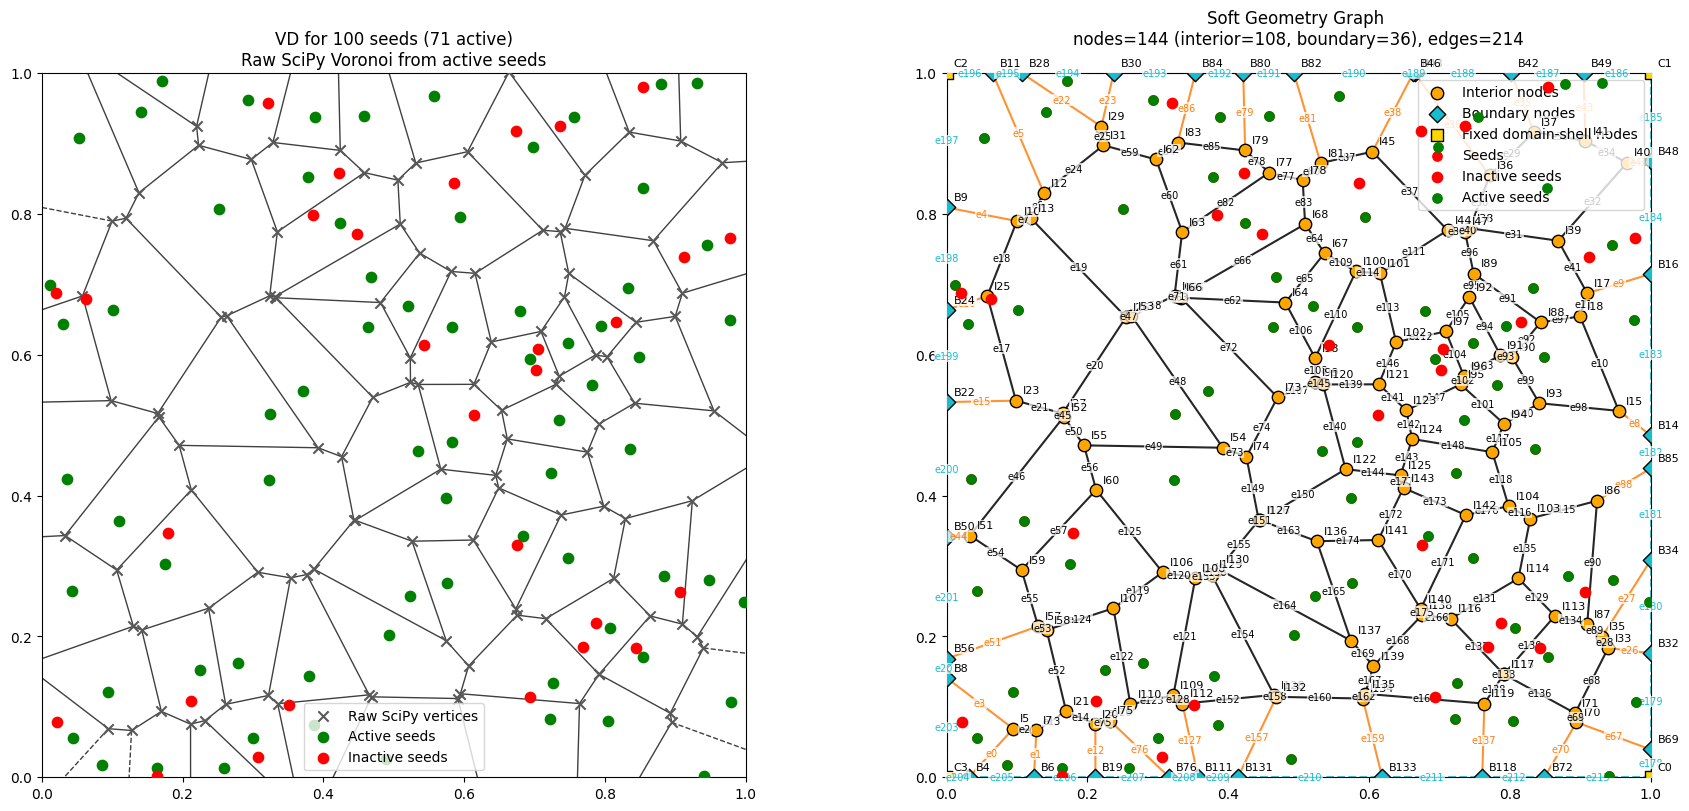

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100c43b91e0_2&reconnect=auto" class="pyvi…

near_duplicate_pair
grad finite: True


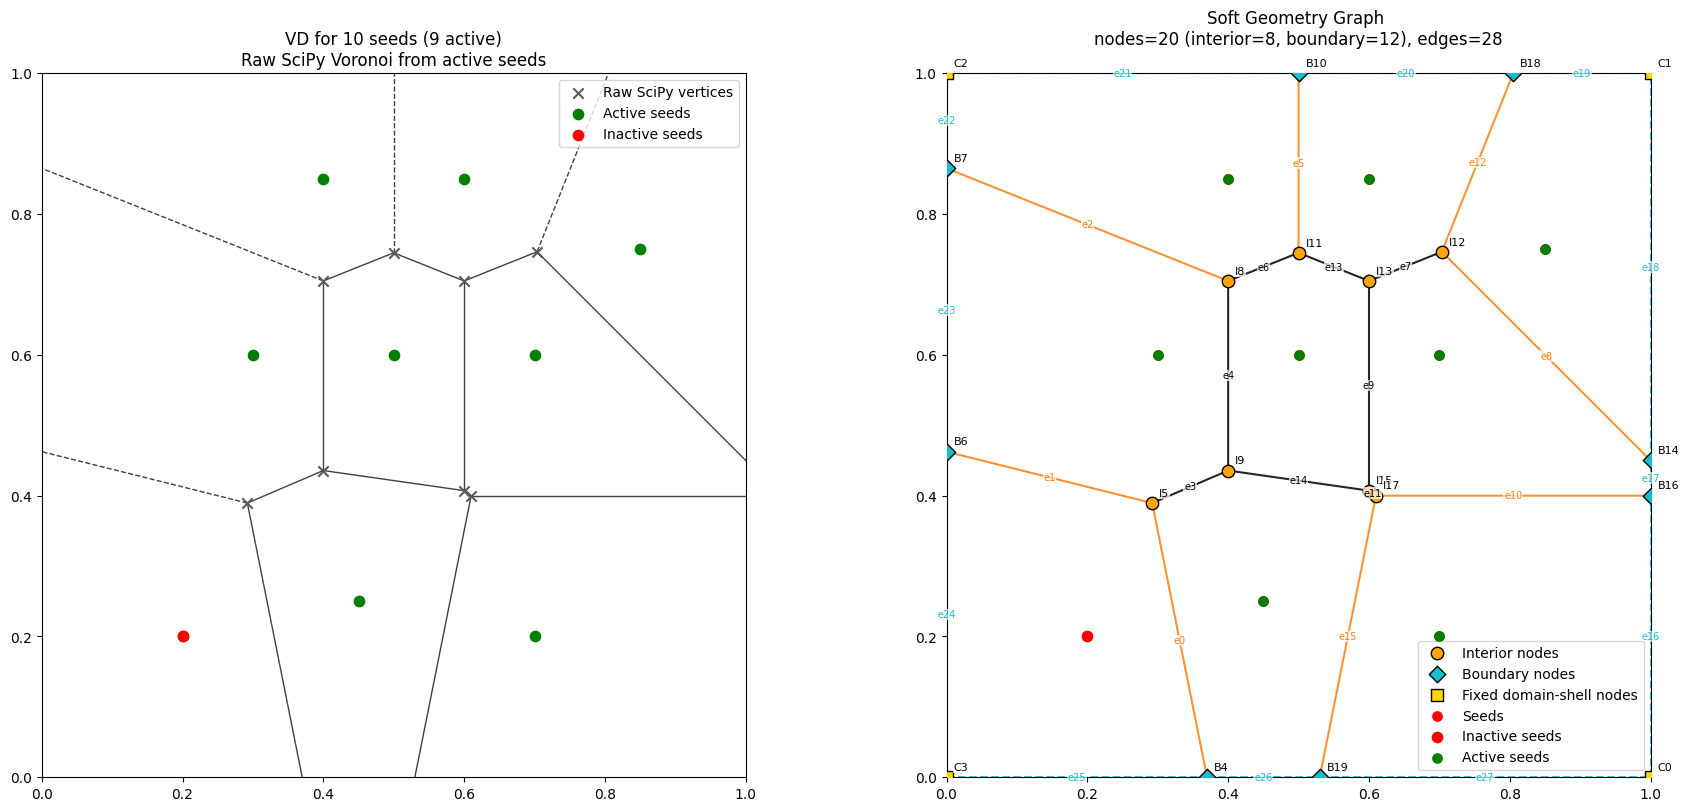

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100fe01a950_3&reconnect=auto" class="pyvi…

clustered_dense
grad finite: True


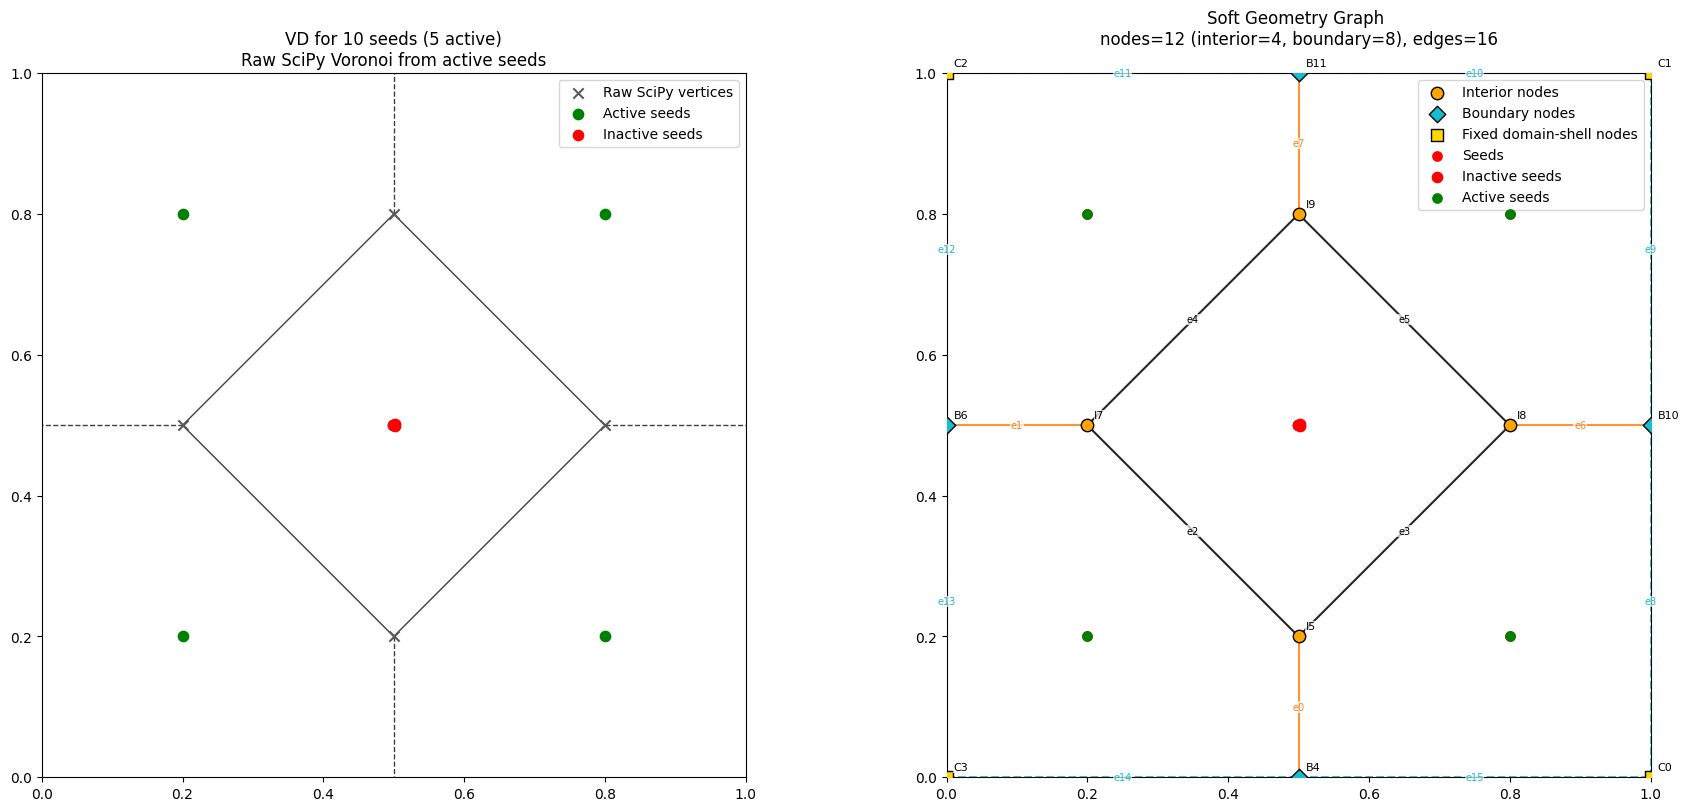

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100c41a3370_4&reconnect=auto" class="pyvi…

nearly_collinear
grad finite: True


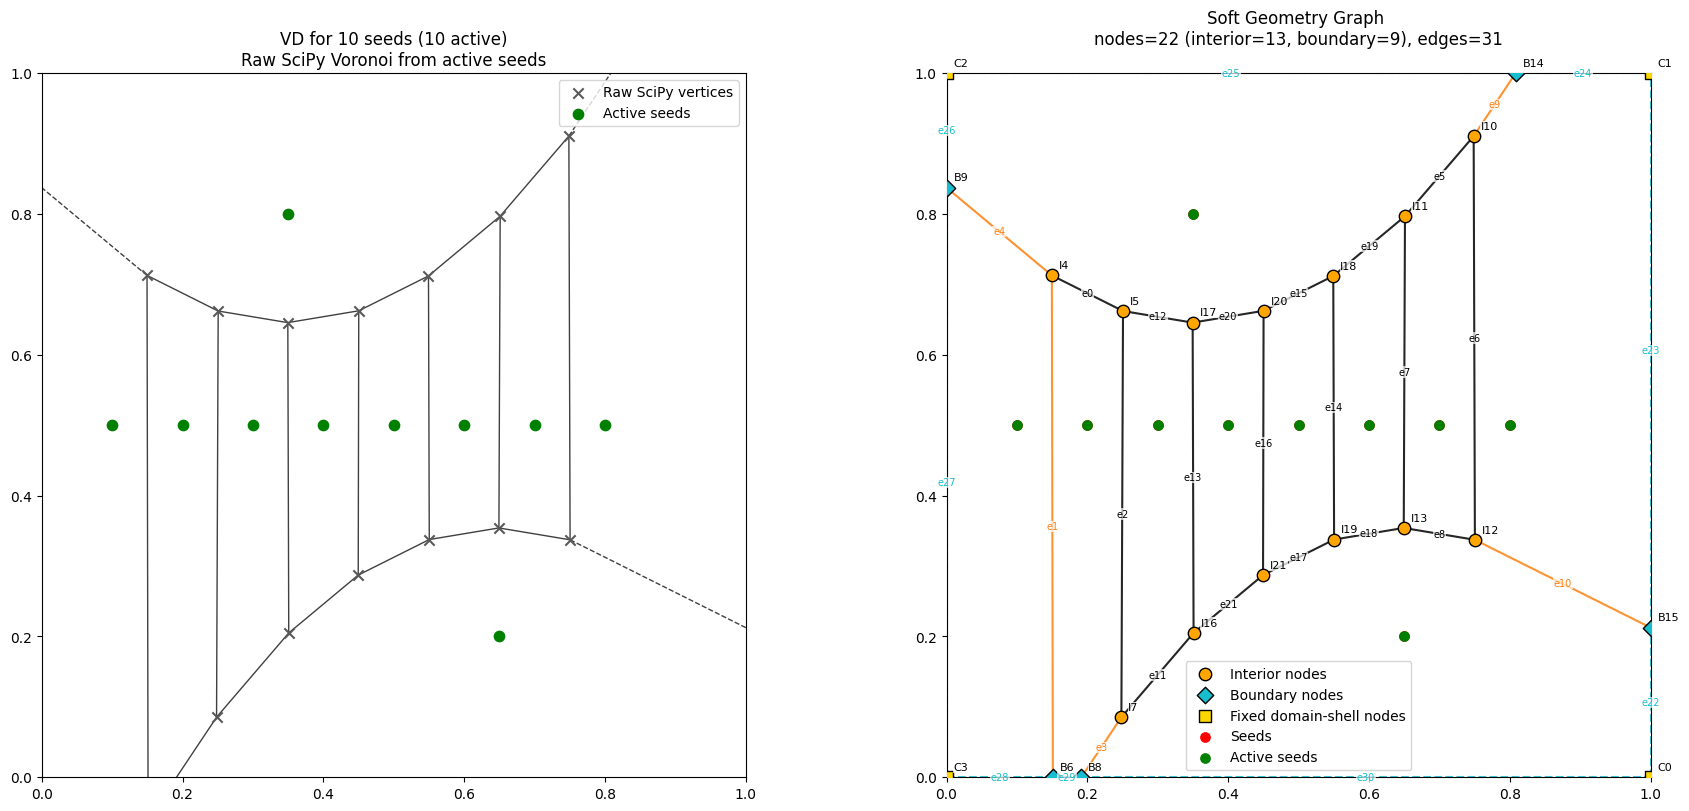

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100c43e0250_5&reconnect=auto" class="pyvi…

nearly_cocircular
grad finite: True


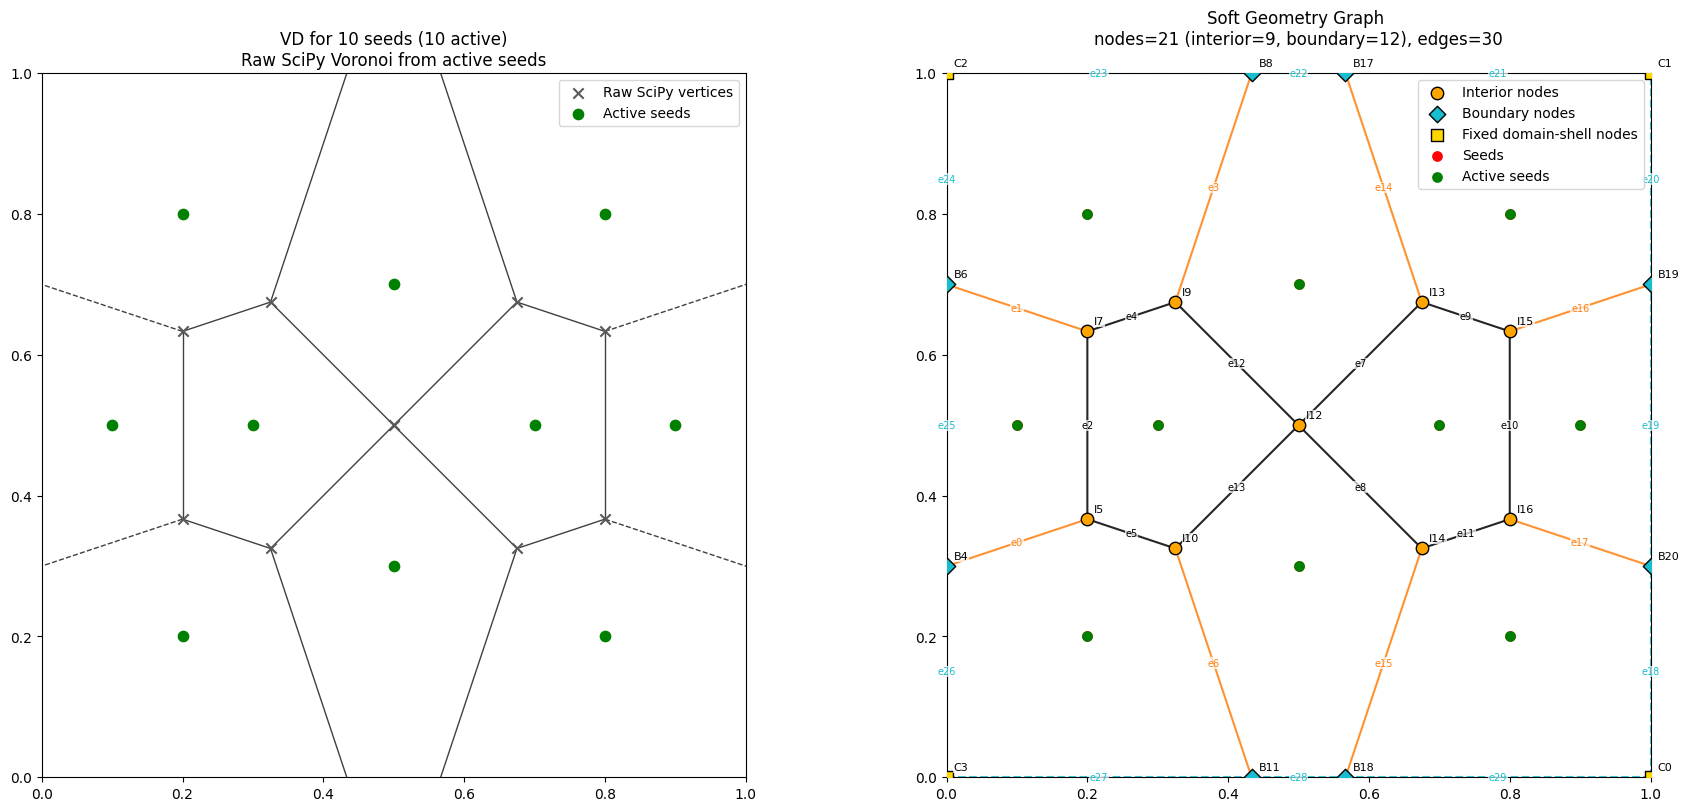

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100b4112f20_6&reconnect=auto" class="pyvi…

perfect_square
grad finite: True


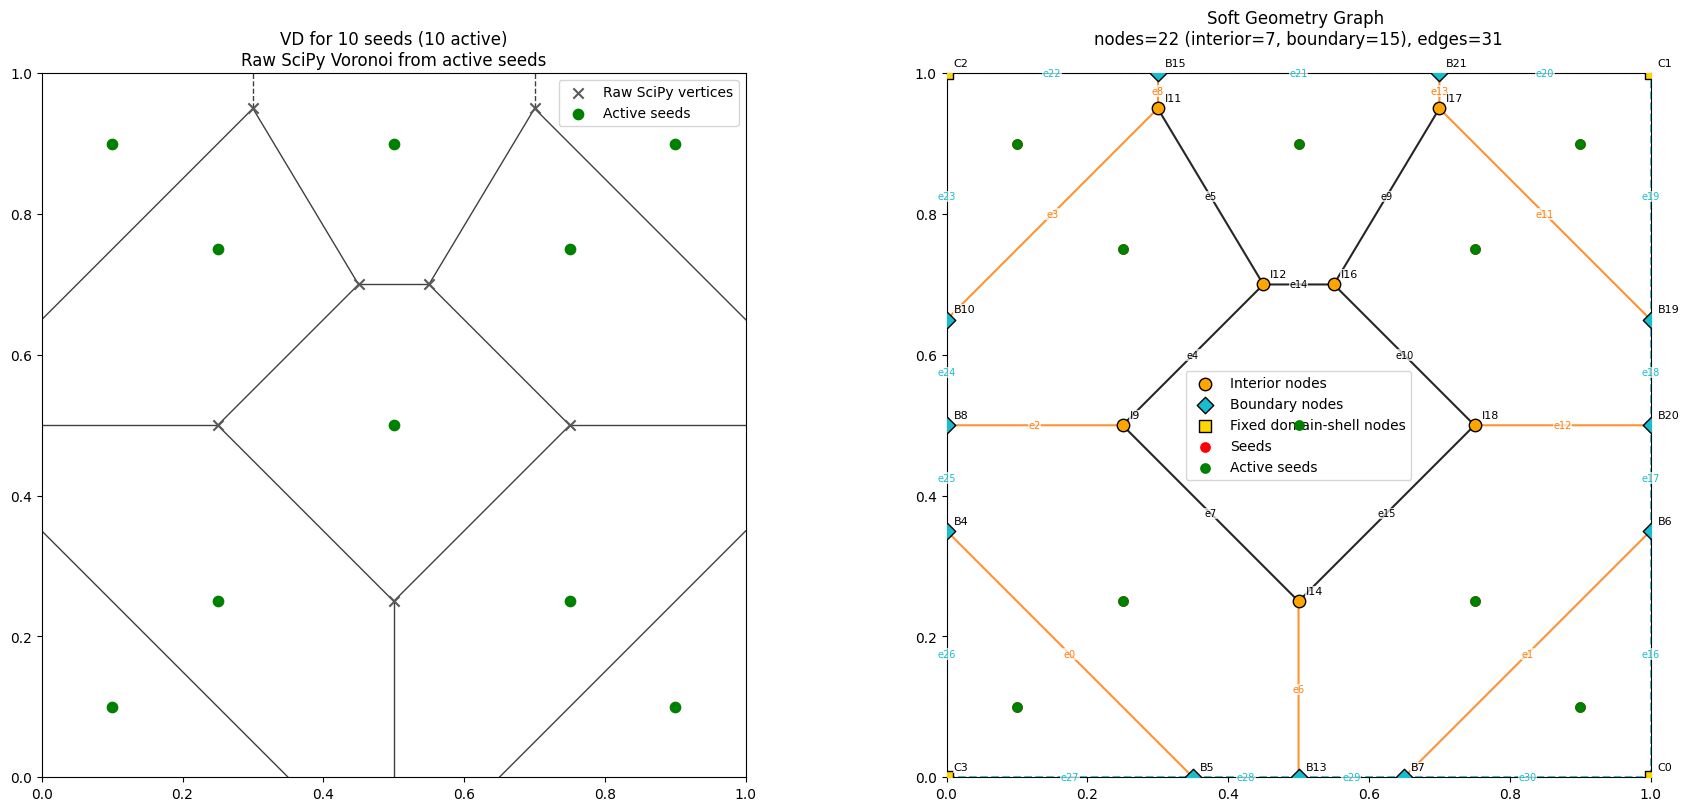

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100af339960_7&reconnect=auto" class="pyvi…

boundary_heavy
grad finite: True


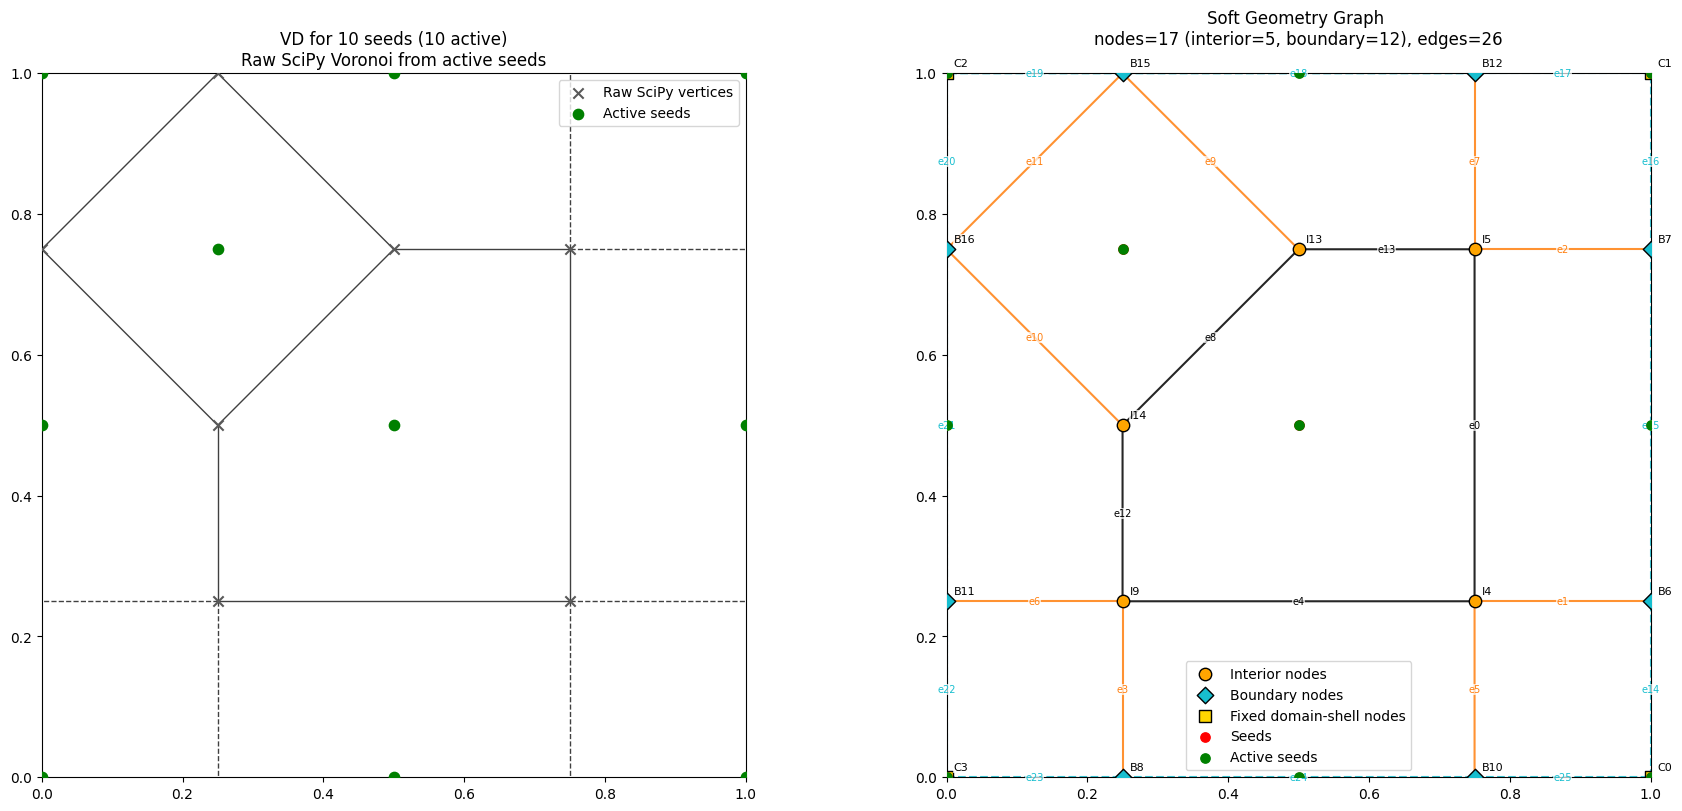

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100af6a0dc0_8&reconnect=auto" class="pyvi…

near_boundary
grad finite: True


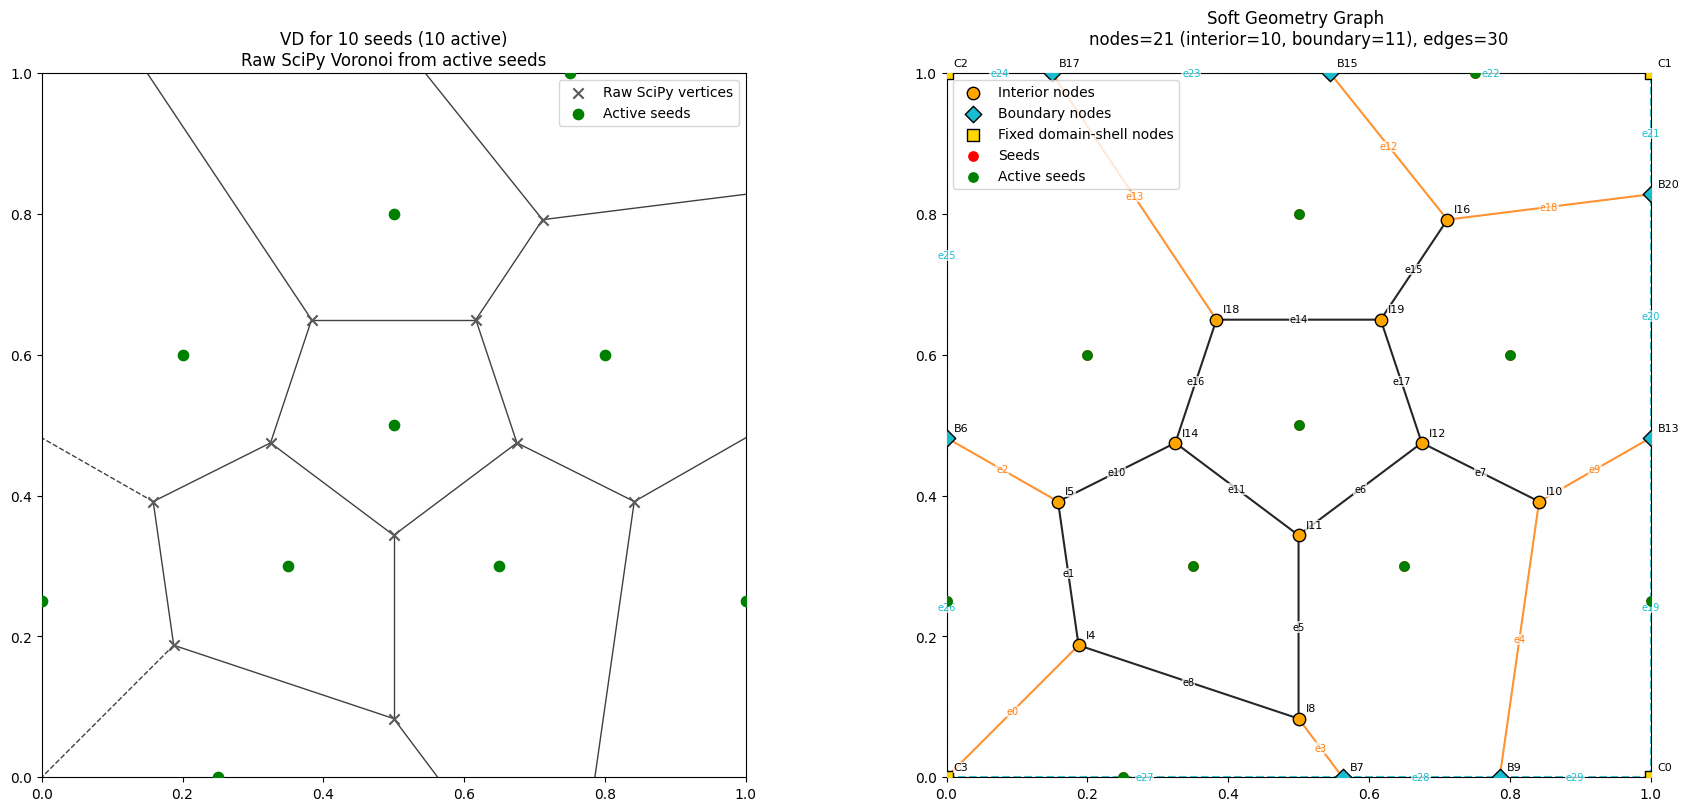

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100bcf3a920_9&reconnect=auto" class="pyvi…

outside_box
grad finite: True


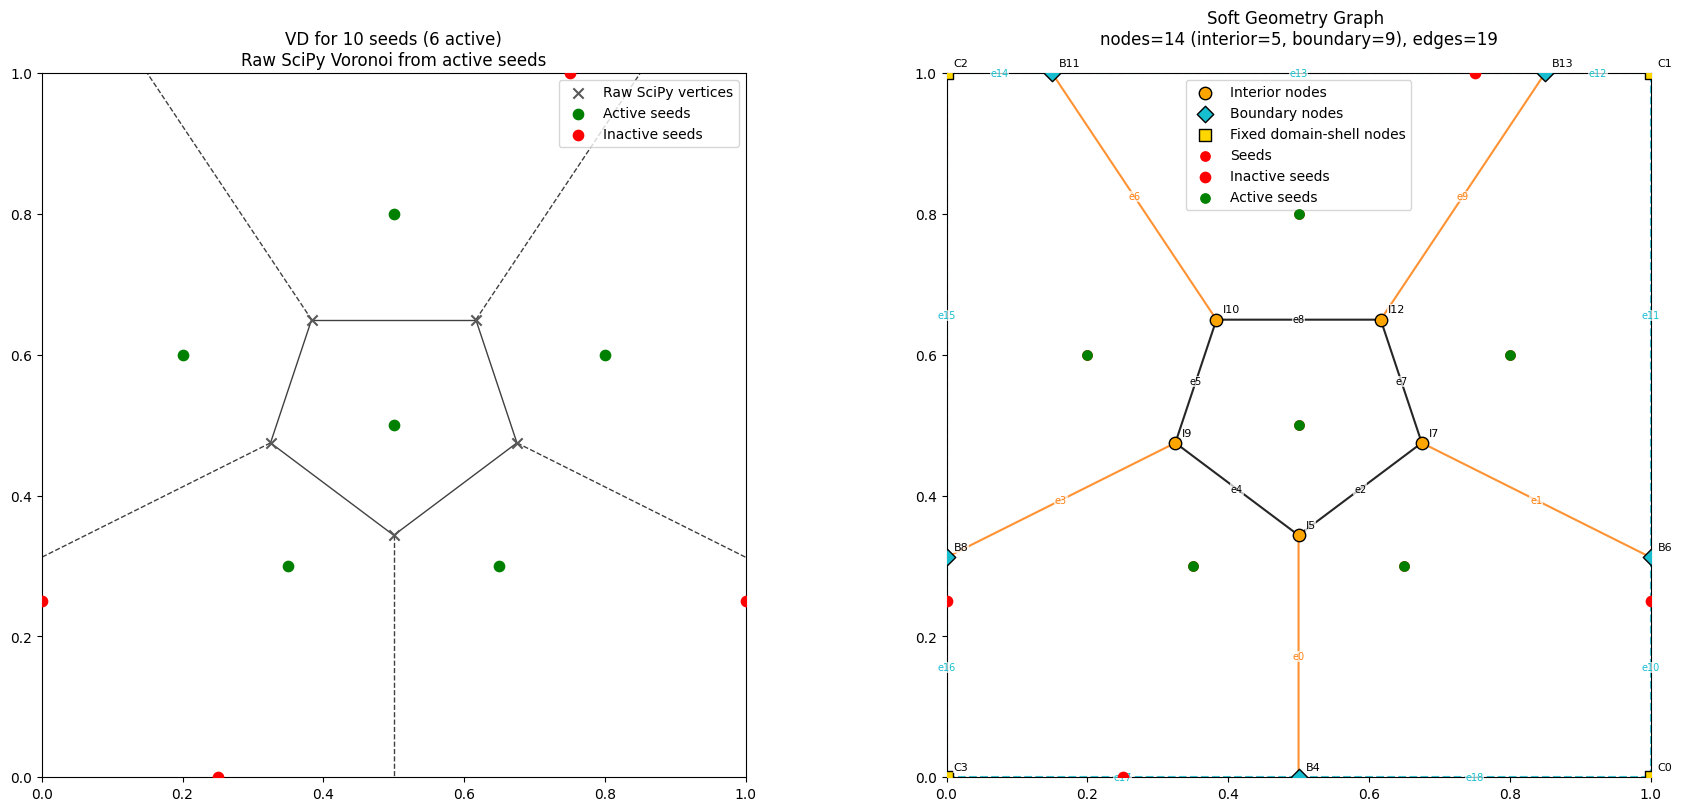

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100c42afb20_10&reconnect=auto" class="pyv…

boundary_grazing
grad finite: True


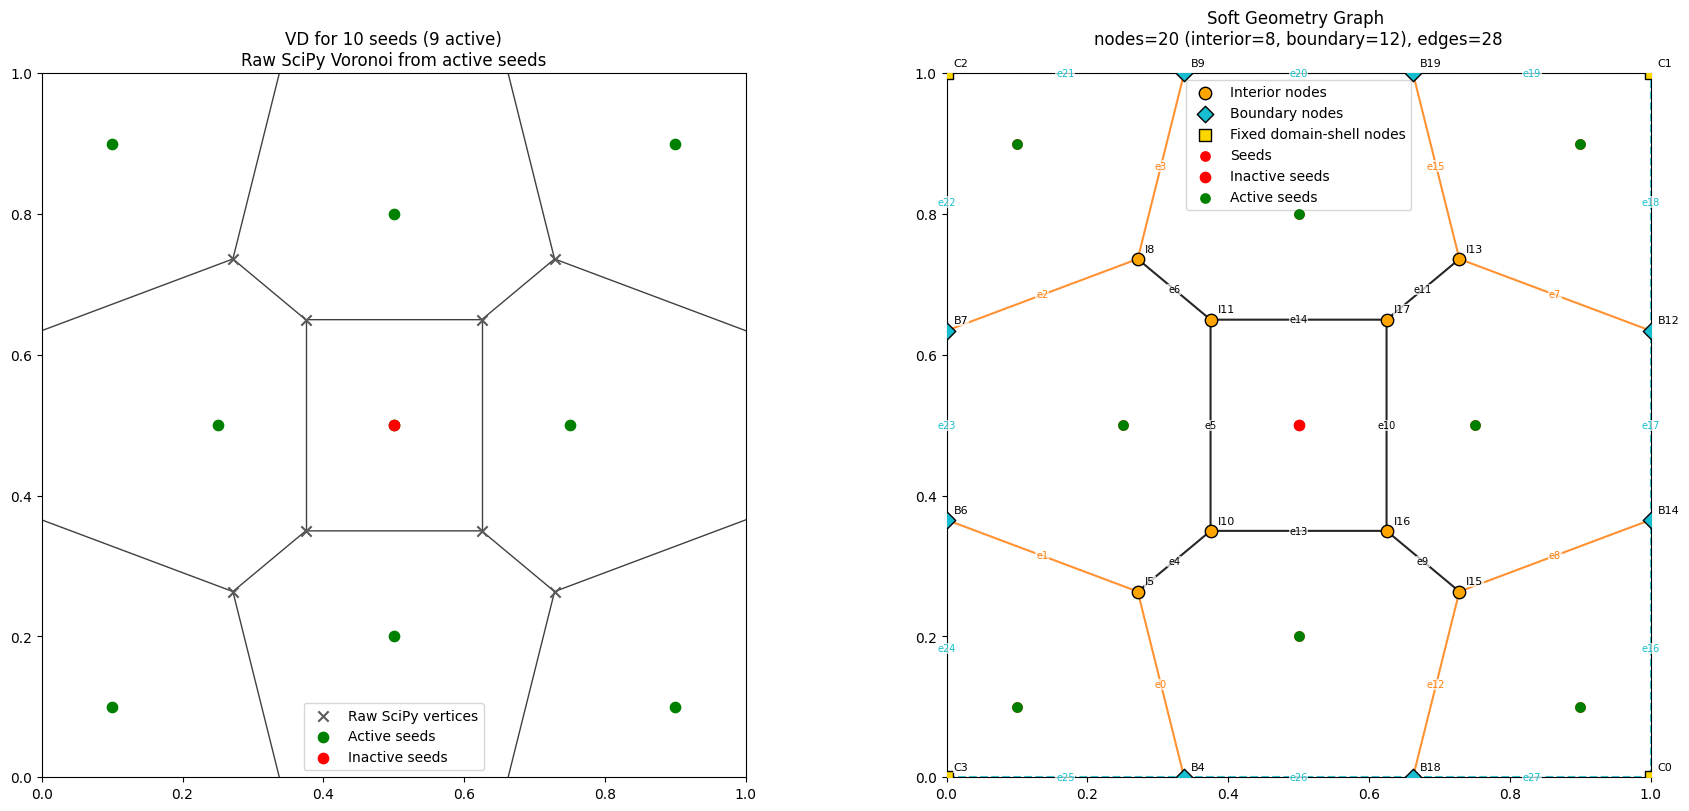

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100c42af2e0_11&reconnect=auto" class="pyv…

skinny_triangles
grad finite: True


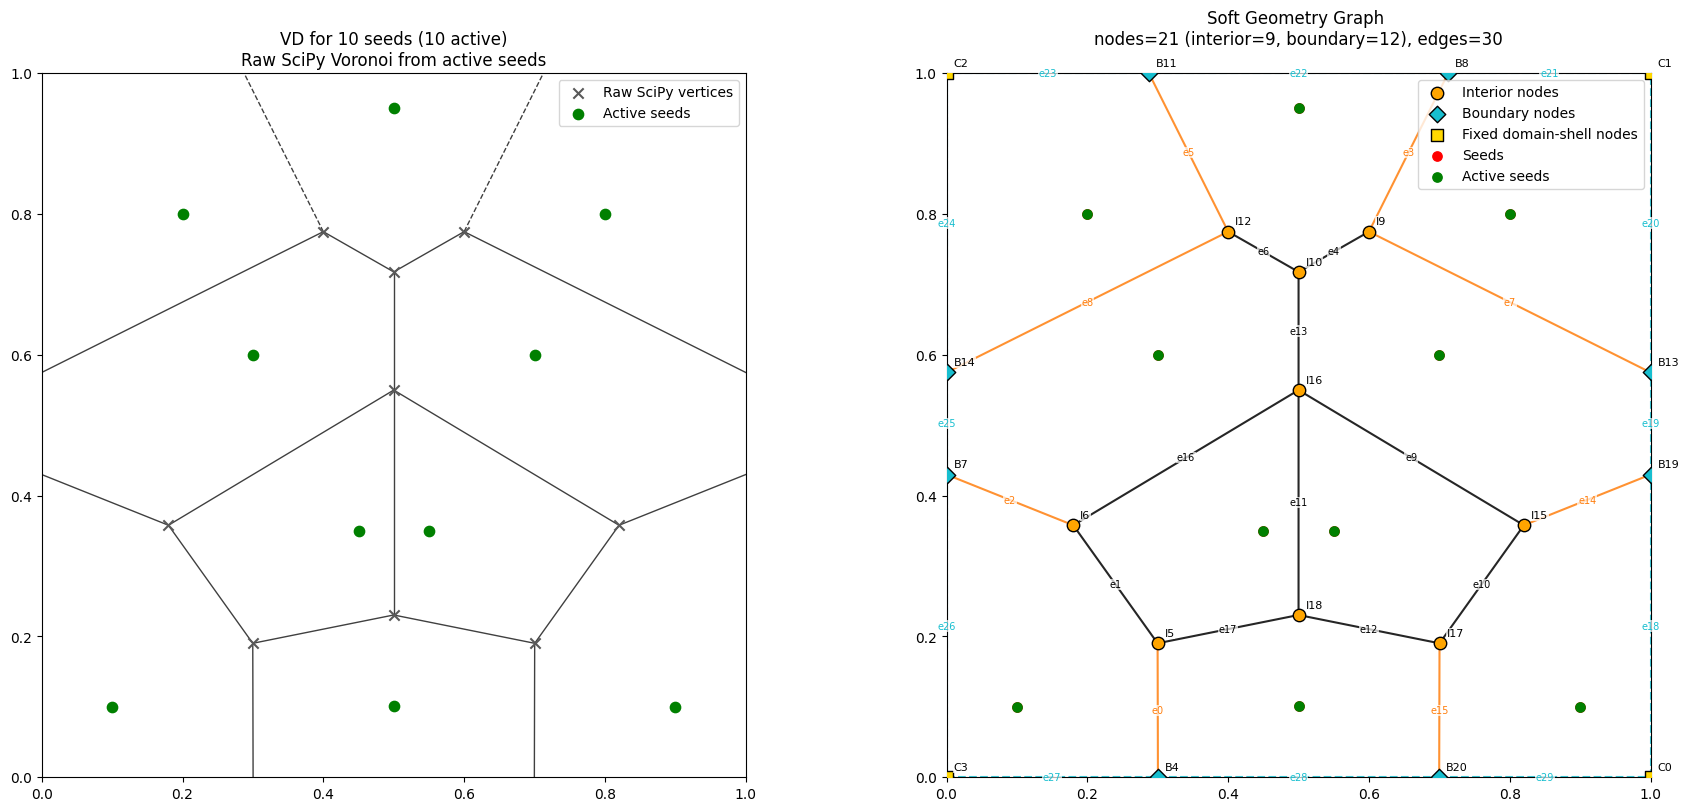

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100fe0c9540_12&reconnect=auto" class="pyv…

optimization_like
grad finite: True


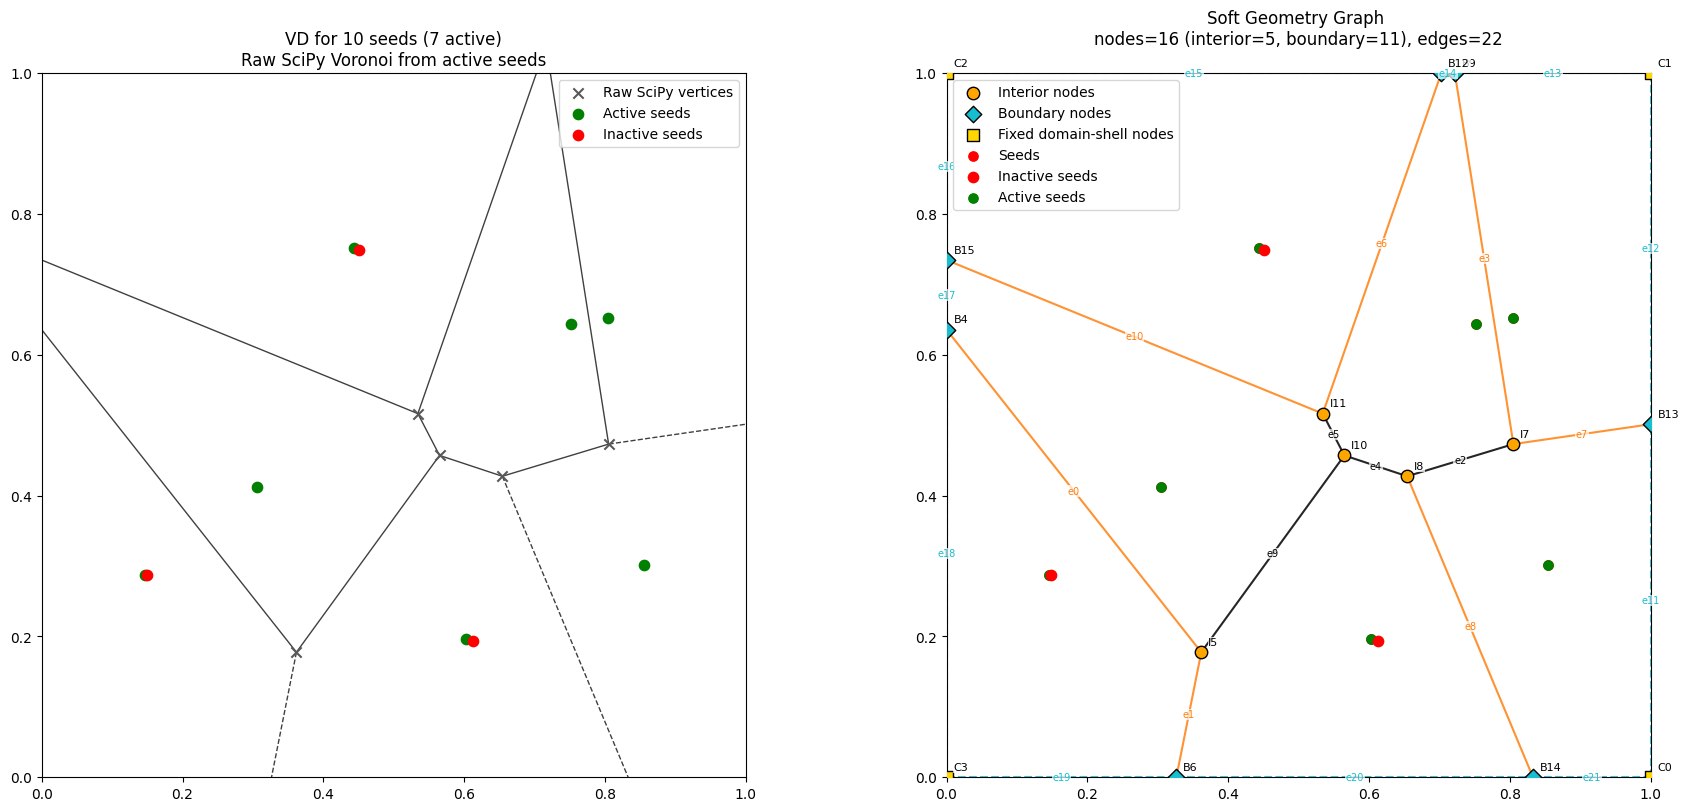

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100c428fd60_13&reconnect=auto" class="pyv…

In [8]:
# Edge-type-aware UV sampling keeps shell edges on the CAD boundary.
DoThis = True
if DoThis:   
    u_periodic = bool(cad_domain["u_periodic"])
    v_periodic = bool(cad_domain["v_periodic"])
    # test_seed_cases11.update(hard_seed_cases)
    # test_seed_cases11.update(test_seed_cases2)
    dec = ContinuousVoronoiDecoder(
        Cad_domain = Face_Cad,
        face_mesh=face_mesh,
        tube_curve_samples=64,
        edge_trim_samples=32,
        tube_density_tau=0.002,
        tube_fiber_tau=0.002,
        face_u_periodic=u_periodic,
        face_v_periodic=v_periodic,
        duplicate_merge_sigma =0.05
    )

    edge_colors = {
        0: "black",
        1: "orange",
        2: "gray",
        3: "orange",
        4: "cyan",
    }

    for name, seed_values in test_seed_cases11.items():

        seeds = seed_values.detach().clone().requires_grad_(True)
        N = seeds.shape[0]
        print(name)
        w_raw_value =0.1
        w_raw = torch.full(
            (N, N),
            w_raw_value,
            dtype=seeds.dtype,
            device=seeds.device,
        )

        out = dec(
            seeds_uv=seeds,
            w_raw=w_raw,
            generate_density_fiber =False    ,
        )

        graph = out["graph"]

        loss = graph["nodes_uv"].sum()
        loss.backward()
        #print("grad finite:", torch.isfinite(seeds.grad).all())
        print("grad finite:", torch.isfinite(seeds.grad).all().item())
        # print("grad norm:", seeds.grad.norm().item())
        # print(out["seed_activation_diagnostics"])
        # print("active ids:", out["active_seed_ids"].detach().cpu().tolist())

        dec.plot_scipy_vs_generated_graph(
            seeds,
            out=out,
            cad_domain=Face_Cad,
            show_node_ids=True,
            show_edge_ids=True,
            node_id_fontsize=8,
            print_node_table=False,
        )


        curves_np = out["edge_curves_xyz"].detach().cpu().numpy()
        edge_type = graph["edge_type"].detach().cpu()

        plotter = pv.Plotter()

        # For visualizing core curves, use a small display radius.
        # For physical radius from decoder, inspect out["centerline_radius"].
        display_radius = 10 if w_raw_value == 0.0 else float(out["centerline_radius"].detach().cpu())

        for edge_id, points in enumerate(curves_np):
            if points.shape[0] < 2:
                print("skip edge", edge_id, "too few points")
                continue

            if not np.isfinite(points).all():
                print("skip edge", edge_id, "non-finite points")
                continue

            length = np.linalg.norm(points[1:] - points[:-1], axis=1).sum()
            if length < 1e-10:
                print("skip edge", edge_id, "zero-length curve", "type", int(edge_type[edge_id]))
                continue

            polyline = pv.PolyData(points)
            polyline.lines = np.concatenate(
                ([len(points)], np.arange(len(points)))
            ).astype(np.int64)

            tube = polyline.tube(radius=display_radius, n_sides=24)

            if tube.n_points == 0:
                print("skip edge", edge_id, "empty tube", "type", int(edge_type[edge_id]))
                continue

            plotter.add_mesh(
                tube,
                color=edge_colors.get(int(edge_type[edge_id]), "gray"),
                smooth_shading=True,
            )

        plotter.show()
   

        # print()
        # # attach fiber vectors to mesh points
        # xyz = face_mesh["points_xyz"]
        # faces = face_mesh["pv_faces"]

        # if torch.is_tensor(xyz):
        #     xyz = xyz.detach().cpu().numpy()
        # if torch.is_tensor(faces):
        #     faces = faces.detach().cpu().numpy()

        # mesh_vis = pv.PolyData(xyz, faces)
        # fiber = out["fiber3d"].detach().cpu().numpy()
        # rho = out["rho"].detach().cpu().numpy()
        # mesh_vis.point_data["fiber"] = fiber
        # mesh_vis.point_data["density"] = rho

        # # optional: show arrows only where material exists
        # mask = rho > 0.3

        # fiber_pts = pv.PolyData(mesh_vis.points[mask])
        # fiber_pts["fiber"] = fiber[mask]
        # fiber_pts["density"] = rho[mask]

        # arrows = fiber_pts.glyph(
        #     orient="fiber",
        #     scale=False,      # constant arrow size
        #     factor=0.2,      # arrow length; tune this
        # )

        # plotter = pv.Plotter()
        # plotter.add_mesh(
        #     mesh_vis,
        #     scalars="density",
        #     cmap="viridis",
        #     clim=[0, 1],
        #     opacity=1,
        #     smooth_shading=True,
        # )

        # plotter.add_mesh(
        #     arrows,
        #     color="black",
        # )

        # plotter.show()
        # print("W_raw", w_raw)
        # print("w_geo:", out["w_geo"].mean().item())
        # print("centerline_radius:", out["centerline_radius"].item())
        # print("rho min/max/mean:", rho.min(), rho.max(), rho.mean())
        # print("distance min/max/mean:", out["tube_distance"].min().item(), out["tube_distance"].max().item(), out["tube_distance"].mean().item())

grad finite: tensor(True)


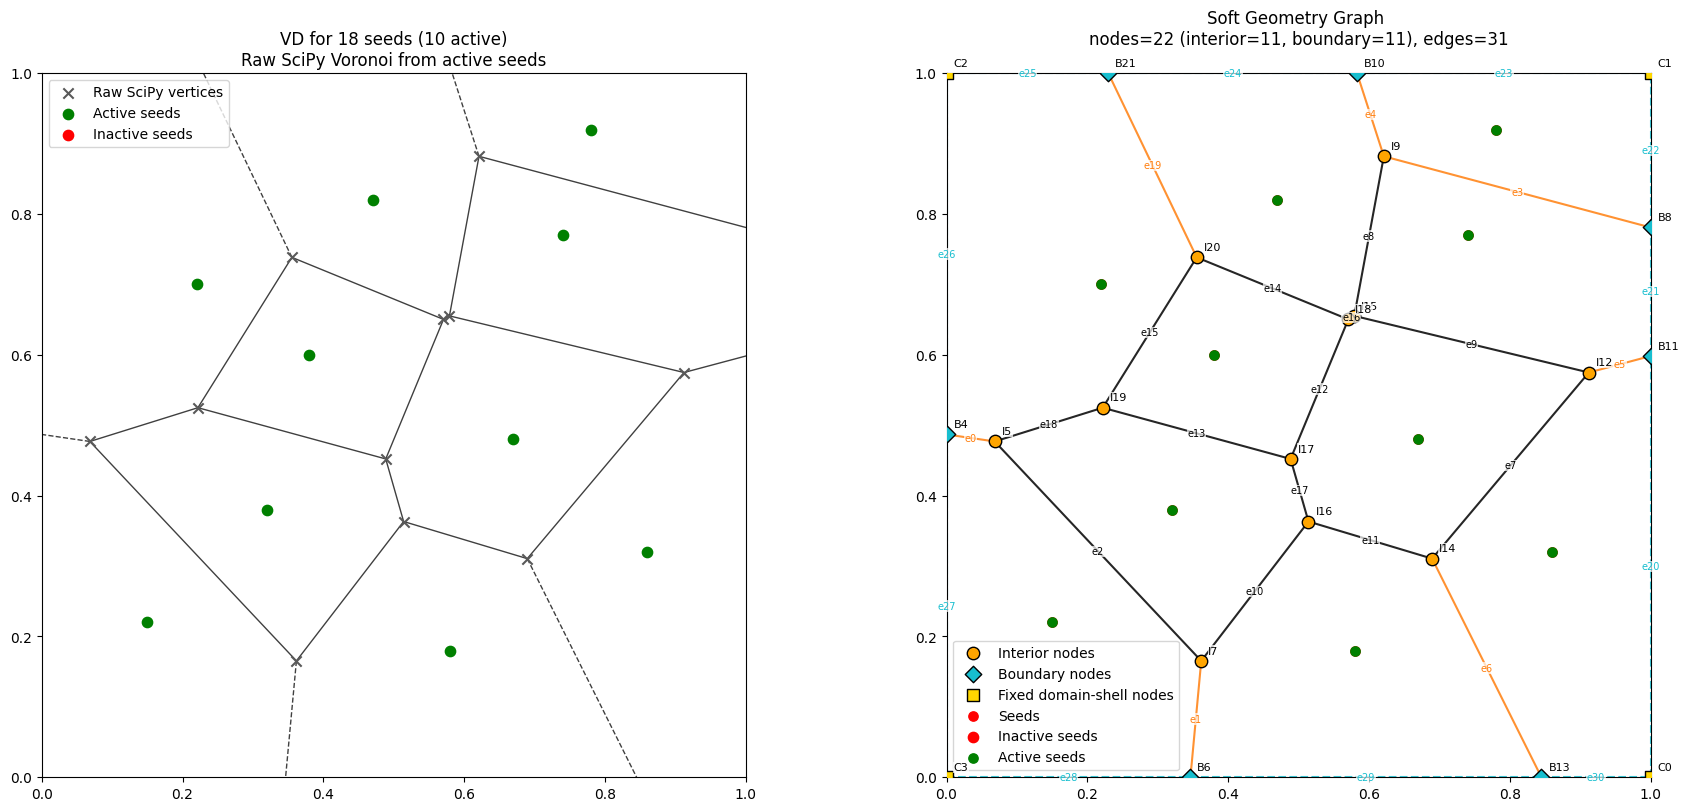

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7101045f47f0_14&reconnect=auto" class="pyv…

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100ada05ed0_15&reconnect=auto" class="pyv…

W_raw tensor([[0.3000, 0.3000, 0.3000,  ..., 0.3000, 0.3000, 0.3000],
        [0.3000, 0.3000, 0.3000,  ..., 0.3000, 0.3000, 0.3000],
        [0.3000, 0.3000, 0.3000,  ..., 0.3000, 0.3000, 0.3000],
        ...,
        [0.3000, 0.3000, 0.3000,  ..., 0.3000, 0.3000, 0.3000],
        [0.3000, 0.3000, 0.3000,  ..., 0.3000, 0.3000, 0.3000],
        [0.3000, 0.3000, 0.3000,  ..., 0.3000, 0.3000, 0.3000]])
w_geo: 0.1612081229686737
centerline_radius: 0.1612081080675125
rho min/max/mean: 0.0 1.0 0.21466924
distance min/max/mean: 0.0 inf inf


In [9]:
# Edge-type-aware UV sampling keeps shell edges on the CAD boundary.
u_periodic = bool(cad_domain["u_periodic"])
v_periodic = bool(cad_domain["v_periodic"])

dec = ContinuousVoronoiDecoder(
    Cad_domain = Face_Cad,
    face_mesh=face_mesh,
    tube_curve_samples=64,
    edge_trim_samples=32,
    tube_density_tau=0.002,
    tube_fiber_tau=0.002,
    face_u_periodic=u_periodic,
    face_v_periodic=v_periodic,
    duplicate_merge_sigma =0.05
    
)

edge_colors = {
    0: "black",
    1: "orange",
    2: "gray",
    3: "orange",
    4: "cyan",
}

for i in range(1, 2):
    N = 50

    # seeds = random_seeds_min_dist(
    #     N=N,
    #     min_dist=0.008,
    #     seed=i * 21,
    #     device=device,
    # ).detach().clone().requires_grad_(True)

    seeds = torch.tensor([
    [0.15, 0.22],
    [0.22, 0.70],
    [0.38, 0.60],
    [0.47, 0.82],
    [0.58, 0.18],
    [0.67, 0.48],
    [0.74, 0.77],
    [0.86, 0.32],
    [0.78, 0.92],
    [0.32, 0.38],
    [0.50, -0.5], 
    [1.5, 0.50], 
    [0.50, 1.5], 
    [-0.5, 0.50], 
    [-0.5, -0.5], [1.5, -0.5], [1.5, 1.5], [-0.5, 1.5],
], dtype=torch.float32).detach().clone().requires_grad_(True)


    # w_raw_value = 0.0 -> core curves only.
    # Increase this, e.g. 0.5, 1.0, 2.0, to increase tube size.
    w_raw_value =0.3
    w_raw = torch.full(
        (N, N),
        w_raw_value,
        dtype=seeds.dtype,
        device=seeds.device,
    )
    generate_density_fiber = True

    out = dec(
        seeds_uv=seeds,
        w_raw=w_raw,
        generate_density_fiber=generate_density_fiber          ,
    )

    graph = out["graph"]

    loss = graph["nodes_uv"].sum()
    loss.backward()
    print("grad finite:", torch.isfinite(seeds.grad).all())

    dec.plot_scipy_vs_generated_graph(
        seeds,
        out=out,
        cad_domain=Face_Cad,
        show_node_ids=True,
        show_edge_ids=True,
        node_id_fontsize=8,
        print_node_table=False,
    )

    curves_np = out["edge_curves_xyz"].detach().cpu().numpy()
    edge_type = graph["edge_type"].detach().cpu()

    plotter = pv.Plotter()

    # For visualizing core curves, use a small display radius.
    # For physical radius from decoder, inspect out["centerline_radius"].
    display_radius = 0.01 if w_raw_value == 0.0 else float(out["centerline_radius"].detach().cpu())

    for edge_id, points in enumerate(curves_np):
        polyline = pv.PolyData(points)
        polyline.lines = np.concatenate(
            ([len(points)], np.arange(len(points)))
        ).astype(np.int64)

        tube = polyline.tube(radius=display_radius, n_sides=24)

        plotter.add_mesh(
            tube,
            color=edge_colors.get(int(edge_type[edge_id]), "gray"),
            smooth_shading=True,
        )

    plotter.show()
    print()

    if generate_density_fiber:
        # attach fiber vectors to mesh points
        xyz = face_mesh["points_xyz"]
        faces = face_mesh["pv_faces"]

        if torch.is_tensor(xyz):
            xyz = xyz.detach().cpu().numpy()
        if torch.is_tensor(faces):
            faces = faces.detach().cpu().numpy()

        mesh_vis = pv.PolyData(xyz, faces)
        fiber = out["fiber3d"].detach().cpu().numpy()
        rho = out["rho"].detach().cpu().numpy()
        mesh_vis.point_data["fiber"] = fiber
        mesh_vis.point_data["density"] = rho

        # optional: show arrows only where material exists
        mask = rho > 0.3

        fiber_pts = pv.PolyData(mesh_vis.points[mask])
        fiber_pts["fiber"] = fiber[mask]
        fiber_pts["density"] = rho[mask]

        arrows = fiber_pts.glyph(
            orient="fiber",
            scale=False,      # constant arrow size
            factor=0.2,      # arrow length; tune this
        )

        plotter = pv.Plotter()
        plotter.add_mesh(
            mesh_vis,
            scalars="density",
            cmap="viridis",
            clim=[0, 1],
            opacity=1,
            smooth_shading=True,
        )

        plotter.add_mesh(
            arrows,
            color="black",
        )

        plotter.show()
        print("W_raw", w_raw)
        print("w_geo:", out["w_geo"].mean().item())
        print("centerline_radius:", out["centerline_radius"].item())
        print("rho min/max/mean:", rho.min(), rho.max(), rho.mean())
        print("distance min/max/mean:", out["tube_distance"].min().item(), out["tube_distance"].max().item(), out["tube_distance"].mean().item())

In [10]:
Include_FEM= True
LoadingCase = "NPW"  # "Tensile" or "Compression"

voxel_size = (dx+dy+dz)/90
#fixed_height_shell= voxel_size*2
fixed_height_shell= 0.5
tangential_tol = voxel_size*0.8

if(Include_FEM):
    # ============================================================
    # Choose ONE load case below.
    # Comment out the other two sections.
    # ============================================================


    # ------------------------------------------------------------
    # 1) Tensile / Compression
    # ------------------------------------------------------------
    # Use this when you want to pull or push the shell along one axis.
    #
    # load_case:
    #   "tensile_compression", "tensile", or "compression"
    #
    # BC_dir:
    #   Axis of loading: "x", "y", or "z".
    #   The min side of this axis is fixed.
    #   The max side of this axis receives the force.
    #
    # Load_magnitude:
    #   Positive value pulls in +BC_dir direction.
    #   Negative value pushes/compresses in -BC_dir direction.
    #
    # # Example:
    # shell_problem = ThickenShell(
    #     thickness=fixed_height_shell,
    #     BC_dir="x",
    #     Load_magnitude=1e-3,
    #     voxel_size=voxel_size,
    #     extra_layers=1,
    #     tensors=face_mesh,
    #     tangential_tol=tangential_tol,
    #     load_case="tensile_compression",
    # )


    # ------------------------------------------------------------
    # 2) Three-Point Bending
    # ------------------------------------------------------------
    # Use this when you want two supports at the ends and a load in the middle.
    #
    # load_case:
    #   "three_point_bending", "threepoint_bending", or "3_point_bending"
    #
    # BC_dir:
    #   Span direction of the part.
    #   Supports are placed at min and max sides of this axis.
    #   The load is applied near the middle of this axis.
    #
    # load_dir:
    #   Direction of the bending force: "x", "y", or "z".
    #
    # Load_magnitude:
    #   Force applied at the middle.
    #   Sign controls direction along load_dir.
    #
    # load_surface_dir:
    #   Optional. Restricts the middle load nodes to one outer surface.
    #   Example: load_surface_dir="z", load_surface_side="max"
    #   means apply the middle force only on the top z surface.
    #
    # load_surface_side:
    #   "min" or "max" side of load_surface_dir.
    #
    # Example:
    shell_problem = ThickenShell(
        thickness=fixed_height_shell,
        BC_dir="x",
        Load_magnitude=0.0001,
        voxel_size=voxel_size,
        extra_layers=1,
        tensors=face_mesh,
        tangential_tol=tangential_tol,
        load_case="three_point_bending",
        load_dir="z",
        load_surface_dir="z",
        load_surface_side="Max",
    )


    # ------------------------------------------------------------
    # 3) Torsion / Twist
    # ------------------------------------------------------------
    # Use this when you want to twist the shell around one axis.
    #
    # load_case:
    #   "torsion", "twist", or "torque"
    #
    # BC_dir:
    #   Axis of twisting: "x", "y", or "z".
    #
    # fixed_side:
    #   Which end of BC_dir is fixed: "min" or "max".
    #
    # force_side:
    #   Which end receives the torque.
    #   Must be opposite to fixed_side.
    #   If omitted, the code automatically chooses the opposite side.
    #
    # Load_magnitude:
    #   Total torque magnitude.
    #   Sign controls twist direction.
    #
    # Example:
    # shell_problem = ThickenShell(
    #     thickness=fixed_height_shell,
    #     BC_dir="y",
    #     Load_magnitude=0.1,
    #     voxel_size=voxel_size,
    #     extra_layers=1,
    #     tensors=face_mesh,
    #     tangential_tol=tangential_tol,
    #     load_case="torsion",
    #     fixed_side="min",
    #     force_side="max",
    # )

    # shell_problem =None
    # fem =None
    fem = run_fem_loss.NeuralTOMOFEM(shell_problem, device=device, isotropic=False)
    shell_problem.debug_voxel_stats()
    loading_img = shell_problem.show_voxels_surface_and_bc(
        return_img=True,
        off_screen=True,
        window_size=(560, 430),
        show=True,
    )
else:
    shell_problem = None
    fem = None
    loading_img = None   

=== Voxel Stats ===
brep_bbox: {'xmin': -1e-07, 'xmax': 10.0000001, 'ymin': -1e-07, 'ymax': 10.0000001, 'zmin': -1e-07, 'zmax': 1e-07}
mesh: {'nelx': 50, 'nely': 50, 'nelz': 5, 'elemSize': array([0.22222223, 0.22222223, 0.22222223]), 'type': 'grid'}
elem_centers shape: (5, 50, 50, 3)
node_coords shape: (6, 51, 51, 3)
occupied voxels: 4416
total voxels: 12500
occupancy ratio: 0.35328
voxels with assigned surface samples: 2116
occupied voxels with assigned surface samples: 2116
voxelized volume: 48.460909711275825
thickness: 0.5
voxel_size: 0.22222222888888885
target approx volume (sum(face_areas)*thickness): 50.000003814697266
volume ratio voxel/target: 0.9692181202800423


Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100ada054e0_16&reconnect=auto" class="pyv…

In [15]:
Explanation = "_Npw"
Case_name = shape_path.stem
cfg = TrainingConfig(
    LoadingCasee=LoadingCase,

    decoder_duplicate_merge_sigma = 0.05,
    
    seed_number=20,
    use_balanced_seed_init=False,  # random UV points
    seed_init_fps_seed=11,   

    num_steps=2000,
    target_volfrac= 0.2,

    use_3d_density_filter = False,
    generate_decoder_density_fiber=False,
    filter_radius_3d= 0.1,
    filter_self_weight = 1.0,
    filter_projection_strength= 1.0,
    filter_projection_beta= 8.0,
    filter_projection_eta = 0.5,

    lam_fem=0,
    lam_vol=0,
    lam_rep=2,
    lam_bnd=0.0,
    lam_curve_length =10,
    lam_cell_edge_uniform=0,
    lam_cell_angle_uniform =0,
    lam_cell_radial_uniform =0,

    curve_length_loss_type="log_tolerance_max",
    curve_length_tolerance=0.10,
    curve_length_outlier_weight=5.0,
    curve_length_target=None,

    comp_normalize_by= None,
    normalize_losses= False,
    fem_density_floor=0.005,
    skip_bad_fem_steps=True,

    # Learning Rates
    lr_seed_refine=5e-4,
    lr_independent_seed_offsets=0,
    lr_delta_head=5e-4,
    lr_mlp=1e-4,
    lr_w_head=5e-5,

    freeze_w=True  ,      # important test: forces optimizer to move seeds
    w_const=0.15,       # or suitable strut width


    log_every=100,
    early_stop_start = 0.2,
    patience = 200,


    # Seed Offset Schedule
    Offset_scale=0.15,
    use_independent_seed_offsets=False,
    independent_seed_offset_max=0.05,
    seed_offset_scale_start=0.1,
    seed_offset_scale_final=0.02,
    seed_offset_scale_ramp_frac=1.0,

    allow_seed_outside_domain =False,

    use_rolling_seed_anchors=True,
    seed_anchor_warmup_frac=0.001,
    seed_anchor_momentum=0.20,

    # Seed Spacing / Projection
    collapse_min_seed_dist_factor=10,
    project_seed_spacing_each_step=False,
    seed_projection_iters=4,
    seed_repulsion_sigma = 0.12,


    # Anchor Guards
    guard_seed_anchor_updates=False  ,
    anchor_guard_rep_max=0.30,
    anchor_guard_bnd_max=0.80,
    anchor_guard_vol_eff_min=0.10,
    anchor_guard_width_factor_min=1.20,
    anchor_guard_min_seed_dist_factor=2.0,


    # Numerical / Optimizer Settings
    eps=1e-12,
    scheduler_milestones=(0.8, 0.95),
    scheduler_gamma=0.5,
    save_fem_debug_history=True,
    grad_clip_norm=0.1,

    # TensorBoard Logging
    tensorboard_enabled=True,
    tensorboard_log_root="runs",
    experiment_name=f"{Case_name}{Explanation}",
    tb_flush_secs=10,
    tb_log_histograms_every=100,

    MakeTimelaps=True,
    timelapse_output_folder=f"Case_Studies/{Case_name}{Explanation}",
    timelapse_frame_step=10,
    timelapse_show_3d_tubes=True,
    timelapse_tube_radius_scale=1.0,
    timelapse_tube_n_sides=12,
    debug_anomaly_detection=False,

)

trainer = NN_Trainer(
    generator=Face_Cad,
    viz=viz,
    decoder_cls=ContinuousVoronoiDecoder,
    ppnet_cls=PPNet,
    fem=fem,
    shell_problem=shell_problem,
    config=cfg,
    face_mesh=face_mesh,
)

result = trainer.train(
    shape_path=shape_path,
    face_tensors=[face_mesh],
)

print("best step:", result["best_step"])
print("best score:", result["best_score"])
print("density:", result["Final_shape_density"].shape)
print("fiber:", result["Final_shape_fiber_direction"].shape)
print("seed UV:", result["best_seed_points_uv"].shape)
print("seed XYZ:", result["best_seed_points_xyz"].shape)

TensorBoard log dir: runs/Planar_Npw


Training:   0%|          | 0/2000 [00:00<?, ?it/s]

New best_step=0 | best_score=18.221031 | best_active_units=20.0 | VolFrac=0.000000 | comp=0.000000e+00 | w=7.780987e-02
[00000] | Active Units/Total=20/20 | L_total=1.8221e+01 | L_vol=0.000e+00 L_fem=0.000e+00 L_rep=0.000e+00 L_bnd=0.000e+00 L_curve=1.822e+00 L(min/max/mean/ratio)=2.475e-02/4.347e+00/1.327e+00/175.62 L_cell_edge=0.000e+00 |VolFrac=0.000 (/0.200) os=1.00e-01 comp=0.000e+00 | w=7.781e-02 clr=7.781e-02 rho(min/mean/max)=0.000/0.000/0.000 Δrho=0.00e+00 Δseed=0.00e+00 dmin=5.06e-02 grad_mean=4.71e-04 | Filter Δrho mean=0.00e+00 Filter Δrho max=0.00e+00 Projection Δrho mean=0.00e+00 Projection Δrho max=0.00e+00 | rho_raw_mean=0.000 rho_filtered_mean=0.000 rho_final_mean=0.000 | fem=OK | best=1.8221e+01@0 | best_hard=inf@-1
[00100] | Active Units/Total=20/20 | L_total=2.0105e+00 | L_vol=0.000e+00 L_fem=0.000e+00 L_rep=1.366e-05 L_bnd=0.000e+00 L_curve=2.011e-01 L(min/max/mean/ratio)=3.585e-01/2.288e+00/1.242e+00/6.38 L_cell_edge=0.000e+00 |VolFrac=0.000 (/0.200) os=9.94e-02 c

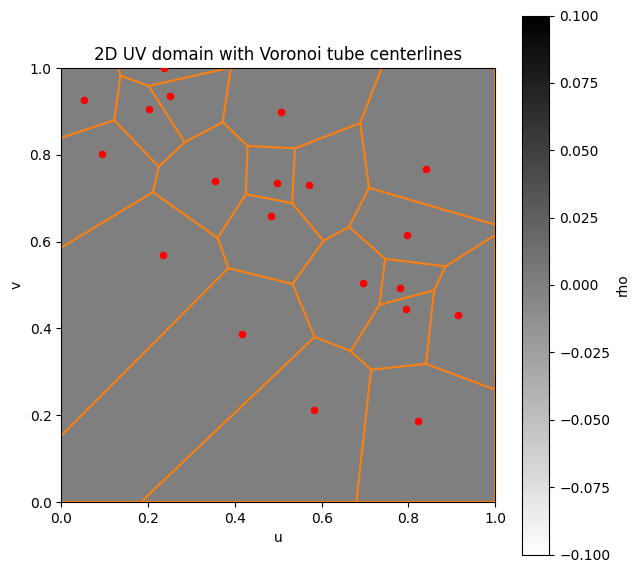

In [16]:
from IPython.display import Image, display
%matplotlib inline
def to_np(x):
    if x is None:
        return None
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

uv = to_np(face_mesh["uv"])
tri = to_np(face_mesh["faces_ijk"]).astype(int)
rho = to_np(result.get("best_rho"))
seeds_uv = to_np(result["best_seeds"][0])
curves_uv = to_np(result["best_edge_curves_uv"])

plt.figure(figsize=(7, 7))

if rho is not None:
    plt.tripcolor(uv[:, 0], uv[:, 1], tri, rho, shading="gouraud", cmap="gray_r")
    plt.colorbar(label="rho")
else:
    plt.triplot(uv[:, 0], uv[:, 1], tri, color="0.85", linewidth=0.5)

if curves_uv is not None:
    for c in curves_uv:
        plt.plot(c[:, 0], c[:, 1], color="tab:orange", linewidth=1.5)

plt.scatter(seeds_uv[:, 0], seeds_uv[:, 1], c="red", s=20, zorder=5)
plt.gca().set_aspect("equal")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("u")
plt.ylabel("v")
plt.title("2D UV domain with Voronoi tube centerlines")
plt.show()

In [17]:

def to_np(x):
    if x is None:
        return None
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

points_xyz = to_np(face_mesh["points_xyz"])
faces = to_np(face_mesh["faces_ijk"]).astype(int)
curves_xyz = to_np(result["best_edge_curves_xyz"])
seeds_xyz = to_np(result["best_seed_points_xyz"])

pv_faces = np.hstack([
    np.full((faces.shape[0], 1), 3, dtype=np.int64),
    faces.astype(np.int64),
]).ravel()

plotter = pv.Plotter()
surf = pv.PolyData(points_xyz, pv_faces)
plotter.add_mesh(surf, color="white", opacity=0.25, show_edges=False)

tube_radius = 0.05  # adjust if too thin/thick

for c in curves_xyz:
    if c.shape[0] < 2:
        continue
    line = pv.PolyData(c.astype(np.float32))
    line.lines = np.hstack([[c.shape[0]], np.arange(c.shape[0])]).astype(np.int64)
    tube = line.tube(radius=tube_radius, n_sides=12)
    plotter.add_mesh(tube, color="orange", smooth_shading=True)

if seeds_xyz is not None:
    plotter.add_mesh(
        pv.PolyData(seeds_xyz.astype(np.float32)),
        color="red",
        point_size=10,
        render_points_as_spheres=True,
    )
plotter.add_axes()
plotter.show()

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x7100203d3160_19&reconnect=auto" class="pyv…

In [14]:
trainer.visualize_result_final(
    result=result,
    points_xyz=face_mesh["points_xyz"],
    faces_ijk=face_mesh["faces_ijk"],
    thr=0.5,
    show_solid=True ,
    show_rho_overlay=False,
)

Widget(value='<iframe src="http://localhost:39283/index.html?ui=P_0x71031196e860_18&reconnect=auto" class="pyv…

(PolyData (0x7100204d6140)
   N Cells:    0
   N Points:   0
   N Strips:   0
   X Bounds:   1.000e+00, -1.000e+00
   Y Bounds:   1.000e+00, -1.000e+00
   Z Bounds:   1.000e+00, -1.000e+00
   N Arrays:   0,
 0.5)